# Demostración de la relación entre PM, DSB y ancho de banda en banda angosta y banda ancha

**Nombre:** Juan Pablo vargas Córdoba

## Introducción

En esta actividad se analiza una señal modulada en fase, conocida como PM, con el fin de estudiar su comportamiento espectral en dos casos: banda angosta y banda ancha.

Para el caso de banda angosta, se busca demostrar que una señal PM puede aproximarse a una señal relacionada con la modulación DSB, debido a que su espectro contiene principalmente la portadora y dos bandas laterales alrededor de la frecuencia portadora.

Por otra parte, para el caso de banda ancha, se analiza cómo el aumento del índice de modulación de fase produce múltiples bandas laterales. Debido a esto, el ancho de banda teórico de una señal PM de banda ancha tiende a infinito.

## Objetivo

Demostrar teórica y gráficamente que una señal PM de banda angosta puede aproximarse a una señal relacionada con DSB, ya que su espectro contiene principalmente la portadora y dos bandas laterales.

Posteriormente, demostrar que una señal PM de banda ancha genera muchas componentes espectrales, por lo que su ancho de banda teórico tiende a infinito.


## Señal moduladora

La señal moduladora o señal mensaje se define como:

$$
m(t) = A_m \cos(2\pi f_m t)
$$

donde $m(t)$ representa el valor de la señal en el tiempo.

El parámetro $A_m$ corresponde a la amplitud de la señal moduladora. Como la función coseno toma valores entre $-1$ y $1$:

$$
-1 \leq \cos(2\pi f_m t) \leq 1
$$

entonces la señal $m(t)$ queda limitada entre:

$$
-A_m \leq m(t) \leq A_m
$$

Por lo tanto, $A_m$ determina el valor máximo y mínimo que puede alcanzar la señal moduladora.

El parámetro $f_m$ corresponde a la frecuencia de la señal moduladora. Esta frecuencia indica cuántos ciclos completos realiza la señal en un segundo y se mide en hertz.

La frecuencia angular de la señal moduladora se define como:

$$
\omega_m = 2\pi f_m
$$

Por tanto, la señal también puede escribirse como:

$$
m(t) = A_m \cos(\omega_m t)
$$

El periodo de la señal moduladora es:

$$
T_m = \frac{1}{f_m}
$$

Esto significa que $T_m$ es el tiempo que tarda la señal en completar un ciclo.


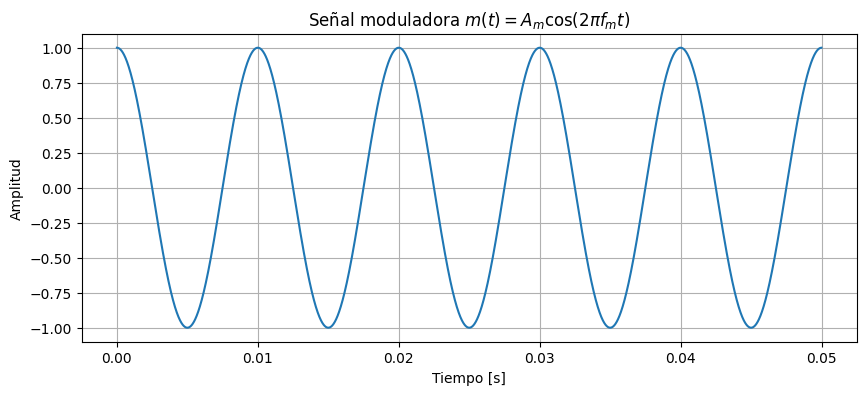

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de la señal moduladora
Am = 1          # Amplitud de la señal moduladora
fm = 100        # Frecuencia de la señal moduladora [Hz]

# Parámetros de simulación
fs = 100000     # Frecuencia de muestreo [Hz]
T = 0.05        # Duración de la simulación [s]

# Vector de tiempo
t = np.arange(0, T, 1/fs)

# Señal moduladora
m_t = Am * np.cos(2 * np.pi * fm * t)

# Gráfica de la señal moduladora
plt.figure(figsize=(10, 4))
plt.plot(t, m_t)
plt.title("Señal moduladora $m(t) = A_m \\cos(2\\pi f_m t)$")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()


## Señal PM

La modulación en fase, PM, consiste en variar la fase instantánea de una señal portadora de acuerdo con la señal moduladora $m(t)$.

La señal PM se define como:

$$
s(t) = A_c \cos(2\pi f_c t + k_p m(t))
$$

donde:

- $A_c$ es la amplitud de la portadora.
- $f_c$ es la frecuencia de la portadora.
- $k_p$ es la sensibilidad de fase.
- $m(t)$ es la señal moduladora.

En una portadora sin modular, la señal es:

$$
c(t) = A_c \cos(2\pi f_c t)
$$

Su fase instantánea es:

$$
\theta_c(t) = 2\pi f_c t
$$

En PM, la fase instantánea cambia a:

$$
\theta_i(t) = 2\pi f_c t + k_p m(t)
$$

Por tanto, la señal moduladora no cambia directamente la amplitud de la portadora, sino su fase.

Si la señal moduladora es sinusoidal:

$$
m(t) = A_m \cos(2\pi f_m t)
$$

entonces:

$$
s(t) = A_c \cos(2\pi f_c t + k_p A_m \cos(2\pi f_m t))
$$

El índice de modulación de fase se define como:

$$
\beta = k_p A_m
$$

Por lo tanto, la señal PM puede escribirse como:

$$
s(t) = A_c \cos(2\pi f_c t + \beta \cos(2\pi f_m t))
$$

El valor de $\beta$ indica la máxima desviación de fase producida por la señal moduladora. Si $\beta$ es pequeño, la señal PM corresponde a banda angosta. Si $\beta$ es grande, corresponde a banda ancha.


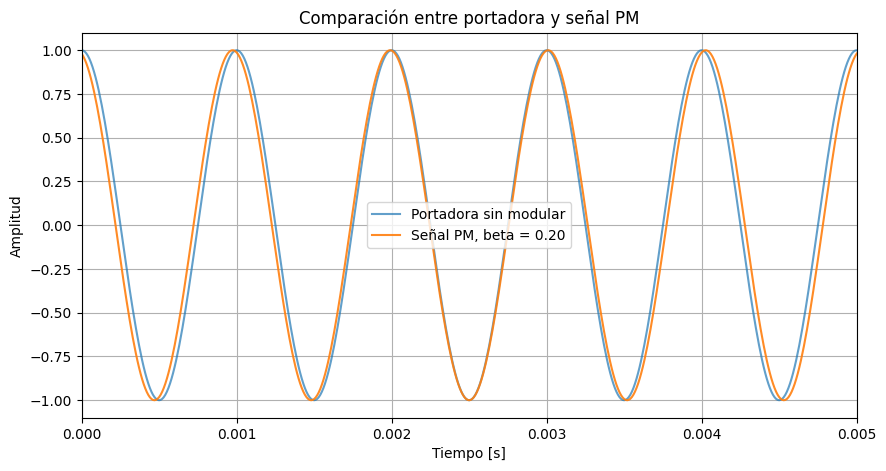

In [15]:
# Parámetros de la portadora y de la modulación PM
Ac = 1          # Amplitud de la portadora
fc = 1000       # Frecuencia de la portadora [Hz]
kp = 0.2        # Sensibilidad de fase [rad/unidad de amplitud]

# Índice de modulación de fase
beta = kp * Am

# Señal portadora sin modular
c_t = Ac * np.cos(2 * np.pi * fc * t)

# Señal PM usando s(t) = Ac cos(2πfct + kp m(t))
s_pm = Ac * np.cos(2 * np.pi * fc * t + kp * m_t)

# Gráfica de la señal portadora y la señal PM
plt.figure(figsize=(10, 5))
plt.plot(t, c_t, label="Portadora sin modular", alpha=0.7)
plt.plot(t, s_pm, label=f"Señal PM, beta = {beta:.2f}", alpha=0.9)
plt.title("Comparación entre portadora y señal PM")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.xlim(0, 0.005)
plt.grid(True)
plt.legend()
plt.show()


## Relación entre PM de banda angosta y DSB

Para una señal PM con moduladora sinusoidal se tiene:

$$
s(t) = A_c \cos(2\pi f_c t + \beta \cos(2\pi f_m t))
$$

donde $\beta$ es el índice de modulación de fase.  
En el caso de banda angosta se cumple que:

$$
\beta \ll 1
$$

Esto significa que la desviación máxima de fase es pequeña. Por ejemplo, valores como:

$$
\beta = 0.1
$$

o

$$
\beta = 0.2
$$

permiten usar aproximaciones de ángulo pequeño.

Para simplificar la demostración, se definen las frecuencias angulares:

$$
\omega_c = 2\pi f_c
$$

$$
\omega_m = 2\pi f_m
$$

Entonces la señal PM puede escribirse como:

$$
s(t) = A_c \cos(\omega_c t + \beta \cos(\omega_m t))
$$

Usando la identidad trigonométrica:

$$
\cos(a+b) = \cos(a)\cos(b) - \sin(a)\sin(b)
$$

con:

$$
a = \omega_c t
$$

$$
b = \beta \cos(\omega_m t)
$$

se obtiene:

$$
s(t) = A_c \left[\cos(\omega_c t)\cos(\beta \cos(\omega_m t)) - \sin(\omega_c t)\sin(\beta \cos(\omega_m t))\right]
$$

Como en banda angosta $\beta$ es pequeño, entonces el término:

$$
\beta \cos(\omega_m t)
$$

también es pequeño, porque $\cos(\omega_m t)$ siempre está entre $-1$ y $1$.

Por lo tanto, se pueden usar las aproximaciones de ángulo pequeño:

$$
\cos(x) \approx 1
$$

$$
\sin(x) \approx x
$$

para valores pequeños de $x$.

En este caso:

$$
x = \beta \cos(\omega_m t)
$$

Entonces:

$$
\cos(\beta \cos(\omega_m t)) \approx 1
$$

y

$$
\sin(\beta \cos(\omega_m t)) \approx \beta \cos(\omega_m t)
$$

Sustituyendo estas aproximaciones en la señal PM:

$$
s(t) \approx A_c \left[\cos(\omega_c t)(1) - \sin(\omega_c t)(\beta \cos(\omega_m t))\right]
$$

Por tanto:

$$
s(t) \approx A_c \cos(\omega_c t) - A_c \beta \sin(\omega_c t)\cos(\omega_m t)
$$

El primer término es la portadora:

$$
A_c \cos(\omega_c t)
$$

El segundo término contiene el producto entre una señal a frecuencia $f_c$ y otra a frecuencia $f_m$:

$$
-A_c \beta \sin(\omega_c t)\cos(\omega_m t)
$$

Usando la identidad trigonométrica:

$$
\sin(a)\cos(b) = \frac{1}{2}\left[\sin(a+b) + \sin(a-b)\right]
$$

se obtiene:

$$
\sin(\omega_c t)\cos(\omega_m t)
=
\frac{1}{2}
\left[
\sin((\omega_c+\omega_m)t)
+
\sin((\omega_c-\omega_m)t)
\right]
$$

Sustituyendo en la expresión aproximada de la señal PM:

$$
s(t) \approx A_c \cos(\omega_c t)
-
\frac{A_c\beta}{2}
\left[
\sin((\omega_c+\omega_m)t)
+
\sin((\omega_c-\omega_m)t)
\right]
$$

Esta expresión muestra que la PM de banda angosta queda formada principalmente por tres componentes espectrales:

$$
f_c
$$

$$
f_c - f_m
$$

$$
f_c + f_m
$$

La componente en $f_c$ corresponde a la portadora.  
La componente en $f_c - f_m$ corresponde a la banda lateral inferior.  
La componente en $f_c + f_m$ corresponde a la banda lateral superior.

Por lo tanto, una señal PM de banda angosta puede aproximarse como una señal compuesta por una portadora y dos bandas laterales alrededor de la frecuencia portadora.

Esta estructura es similar a la de una modulación DSB, ya que en DSB también aparecen dos bandas laterales ubicadas alrededor de la portadora. La diferencia principal es que, en PM de banda angosta, la portadora permanece presente, mientras que en DSB-SC la portadora está suprimida.

Por esta razón, se dice que la PM de banda angosta tiene una relación directa con DSB: su espectro queda concentrado principalmente en dos bandas laterales alrededor de $f_c$.


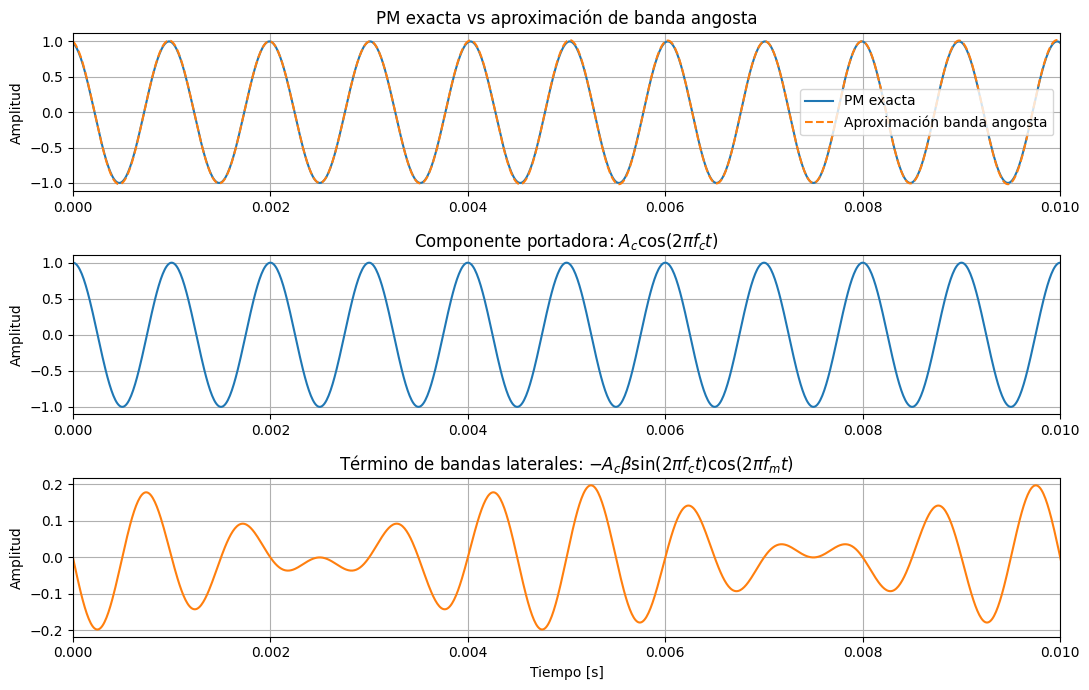

In [16]:
# PM de banda angosta
beta_nb = 0.2

# Señal PM exacta
s_pm_nb = Ac * np.cos(2 * np.pi * fc * t + beta_nb * np.cos(2 * np.pi * fm * t))

# Aproximación de banda angosta:
# s(t) ≈ Ac cos(wc t) - Ac beta sin(wc t) cos(wm t)
s_pm_nb_aprox = (
    Ac * np.cos(2 * np.pi * fc * t)
    - Ac * beta_nb * np.sin(2 * np.pi * fc * t) * np.cos(2 * np.pi * fm * t)
)

# Componentes de la aproximación
portadora = Ac * np.cos(2 * np.pi * fc * t)

bandas_laterales_aprox = (
    - Ac * beta_nb * np.sin(2 * np.pi * fc * t) * np.cos(2 * np.pi * fm * t)
)

plt.figure(figsize=(11, 7))

plt.subplot(3, 1, 1)
plt.plot(t, s_pm_nb, label="PM exacta")
plt.plot(t, s_pm_nb_aprox, "--", label="Aproximación banda angosta")
plt.title("PM exacta vs aproximación de banda angosta")
plt.ylabel("Amplitud")
plt.xlim(0, 0.01)
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t, portadora, color="tab:blue")
plt.title("Componente portadora: $A_c \\cos(2\\pi f_c t)$")
plt.ylabel("Amplitud")
plt.xlim(0, 0.01)
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t, bandas_laterales_aprox, color="tab:orange")
plt.title("Término de bandas laterales: $-A_c\\beta\\sin(2\\pi f_c t)\\cos(2\\pi f_m t)$")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.xlim(0, 0.01)
plt.grid(True)

plt.tight_layout()
plt.show()


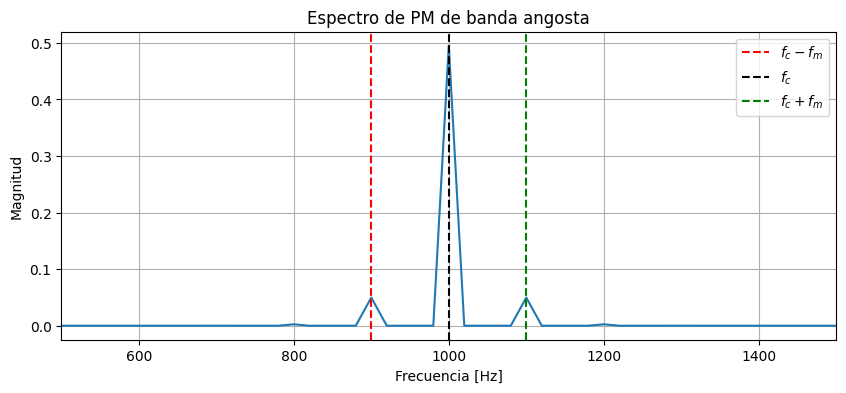

In [17]:
def calcular_espectro(x, fs):
    N = len(x)
    X = np.fft.fft(x)
    f = np.fft.fftfreq(N, 1/fs)

    # Solo frecuencias positivas
    idx = f >= 0
    f_pos = f[idx]
    X_pos = np.abs(X[idx]) / N

    return f_pos, X_pos

f_nb, S_nb = calcular_espectro(s_pm_nb, fs)

plt.figure(figsize=(10, 4))
plt.plot(f_nb, S_nb)
plt.title("Espectro de PM de banda angosta")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(fc - 5*fm, fc + 5*fm)
plt.grid(True)

plt.axvline(fc - fm, color="red", linestyle="--", label="$f_c - f_m$")
plt.axvline(fc, color="black", linestyle="--", label="$f_c$")
plt.axvline(fc + fm, color="green", linestyle="--", label="$f_c + f_m$")

plt.legend()
plt.show()


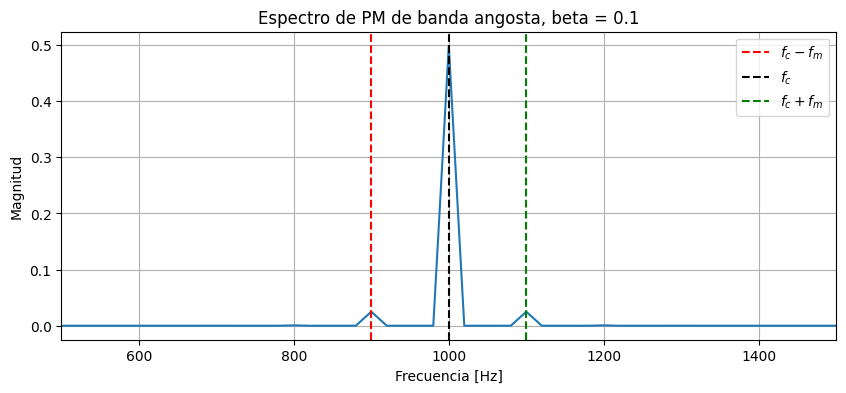

In [18]:
# PM de banda angosta con beta = 0.1
import numpy as np
import matplotlib.pyplot as plt

def calcular_espectro(x, fs):
    N = len(x)
    X = np.fft.fft(x)
    f = np.fft.fftfreq(N, 1/fs)

    # Solo frecuencias positivas
    idx = f >= 0
    f_pos = f[idx]
    X_pos = np.abs(X[idx]) / N

    return f_pos, X_pos

beta_nb2 = 0.1

# Parámetros (reutilizando de celdas anteriores)
Ac = 1          # Amplitud de la portadora
fc = 1000       # Frecuencia de la portadora [Hz]
fm = 100        # Frecuencia de la señal moduladora [Hz]
fs = 100000     # Frecuencia de muestreo [Hz]
T = 0.05        # Duración de la simulación [s]
t = np.arange(0, T, 1/fs)

# Señal PM exacta
s_pm_nb2 = Ac * np.cos(2 * np.pi * fc * t + beta_nb2 * np.cos(2 * np.pi * fm * t))

f_nb2, S_nb2 = calcular_espectro(s_pm_nb2, fs)

plt.figure(figsize=(10, 4))
plt.plot(f_nb2, S_nb2)
plt.title("Espectro de PM de banda angosta, beta = 0.1")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(fc - 5*fm, fc + 5*fm)
plt.grid(True)

plt.axvline(fc - fm, color="red", linestyle="--", label="$f_c - f_m$")
plt.axvline(fc, color="black", linestyle="--", label="$f_c$")
plt.axvline(fc + fm, color="green", linestyle="--", label="$f_c + f_m$")

plt.legend()
plt.show()

## Ancho de banda en PM de banda angosta

En PM de banda angosta se considera que el índice de modulación de fase es pequeño:

$$
\beta \ll 1
$$

Bajo esta condición, la señal PM puede aproximarse como:

$$
s(t) \approx A_c \cos(\omega_c t)
-
\frac{A_c\beta}{2}
\left[
\sin((\omega_c+\omega_m)t)
+
\sin((\omega_c-\omega_m)t)
\right]
$$

Esta expresión muestra que las componentes espectrales principales están ubicadas en:

$$
f_c
$$

$$
f_c - f_m
$$

$$
f_c + f_m
$$

La frecuencia más baja significativa es:

$$
f_{\min} = f_c - f_m
$$

La frecuencia más alta significativa es:

$$
f_{\max} = f_c + f_m
$$

El ancho de banda se define como la diferencia entre la frecuencia máxima y la frecuencia mínima ocupada por la señal:

$$
B = f_{\max} - f_{\min}
$$

Sustituyendo:

$$
B = (f_c + f_m) - (f_c - f_m)
$$

Desarrollando:

$$
B = f_c + f_m - f_c + f_m
$$

Por lo tanto:

$$
B = 2f_m
$$

Así, para PM de banda angosta:

$$
B \approx 2f_m
$$

Este ancho de banda es finito porque solo se consideran significativas la portadora y las dos bandas laterales principales.

El resultado es similar al de una señal DSB, donde el ancho de banda también depende del doble de la frecuencia máxima de la señal moduladora.


Análisis de ancho de banda en PM de banda angosta
Frecuencia de la portadora fc = 1000 Hz
Frecuencia moduladora fm = 100 Hz
Frecuencia mínima significativa fc - fm = 900 Hz
Frecuencia máxima significativa fc + fm = 1100 Hz
Ancho de banda aproximado B ≈ 2fm = 200 Hz


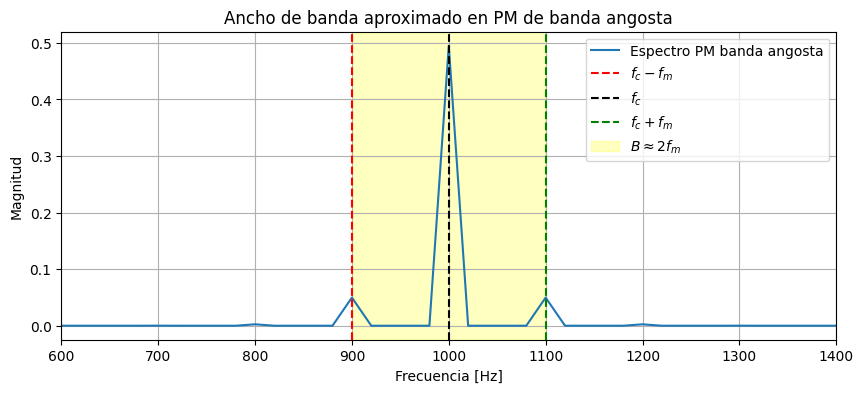

In [19]:
# Ancho de banda aproximado para PM de banda angosta
B_nb = 2 * fm

f_min_nb = fc - fm
f_max_nb = fc + fm

print("Análisis de ancho de banda en PM de banda angosta")
print(f"Frecuencia de la portadora fc = {fc} Hz")
print(f"Frecuencia moduladora fm = {fm} Hz")
print(f"Frecuencia mínima significativa fc - fm = {f_min_nb} Hz")
print(f"Frecuencia máxima significativa fc + fm = {f_max_nb} Hz")
print(f"Ancho de banda aproximado B ≈ 2fm = {B_nb} Hz")

plt.figure(figsize=(10, 4))
plt.plot(f_nb, S_nb, label="Espectro PM banda angosta")

plt.axvline(f_min_nb, color="red", linestyle="--", label="$f_c - f_m$")
plt.axvline(fc, color="black", linestyle="--", label="$f_c$")
plt.axvline(f_max_nb, color="green", linestyle="--", label="$f_c + f_m$")

plt.axvspan(f_min_nb, f_max_nb, color="yellow", alpha=0.25, label="$B \\approx 2f_m$")

plt.title("Ancho de banda aproximado en PM de banda angosta")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(fc - 4*fm, fc + 4*fm)
plt.grid(True)
plt.legend()
plt.show()


## PM de banda ancha

En PM de banda ancha el índice de modulación de fase cumple:

$$
\beta > 1
$$

En este caso ya no es válida la aproximación de ángulo pequeño usada en banda angosta. La señal PM sigue estando definida por:

$$
s(t) = A_c \cos(2\pi f_c t + \beta \cos(2\pi f_m t))
$$

Para analizar su espectro se usa la expansión en funciones de Bessel:

$$
e^{j\beta \cos(\omega_m t)}
=
\sum_{n=-\infty}^{\infty} j^n J_n(\beta)e^{jn\omega_m t}
$$

donde $J_n(\beta)$ es la función de Bessel de orden $n$.

Como la señal PM puede verse como la parte real de una señal compleja:

$$
s(t) = \Re\left\{A_c e^{j\omega_c t} e^{j\beta \cos(\omega_m t)}\right\}
$$

al sustituir la expansión de Bessel se obtiene:

$$
s(t)
=
\Re\left\{
A_c e^{j\omega_c t}
\sum_{n=-\infty}^{\infty} j^n J_n(\beta)e^{jn\omega_m t}
\right\}
$$

Por lo tanto:

$$
s(t)
=
\Re\left\{
A_c
\sum_{n=-\infty}^{\infty}
j^n J_n(\beta)
e^{j(\omega_c+n\omega_m)t}
\right\}
$$

Esta expresión muestra que aparecen componentes espectrales en:

$$
f_c \pm nf_m
$$

donde:

$$
n = 1, 2, 3, 4, \ldots
$$

Además, también puede aparecer una componente en la frecuencia de la portadora $f_c$, cuya amplitud depende de $J_0(\beta)$.

Como la suma va desde $n=-\infty$ hasta $n=\infty$, teóricamente existen infinitas bandas laterales. Por esta razón, el ancho de banda teórico de una señal PM de banda ancha tiende a infinito.

Sin embargo, en la práctica no todas las bandas laterales tienen amplitud significativa. A medida que $n$ aumenta, muchas componentes se vuelven muy pequeñas y pueden despreciarse.


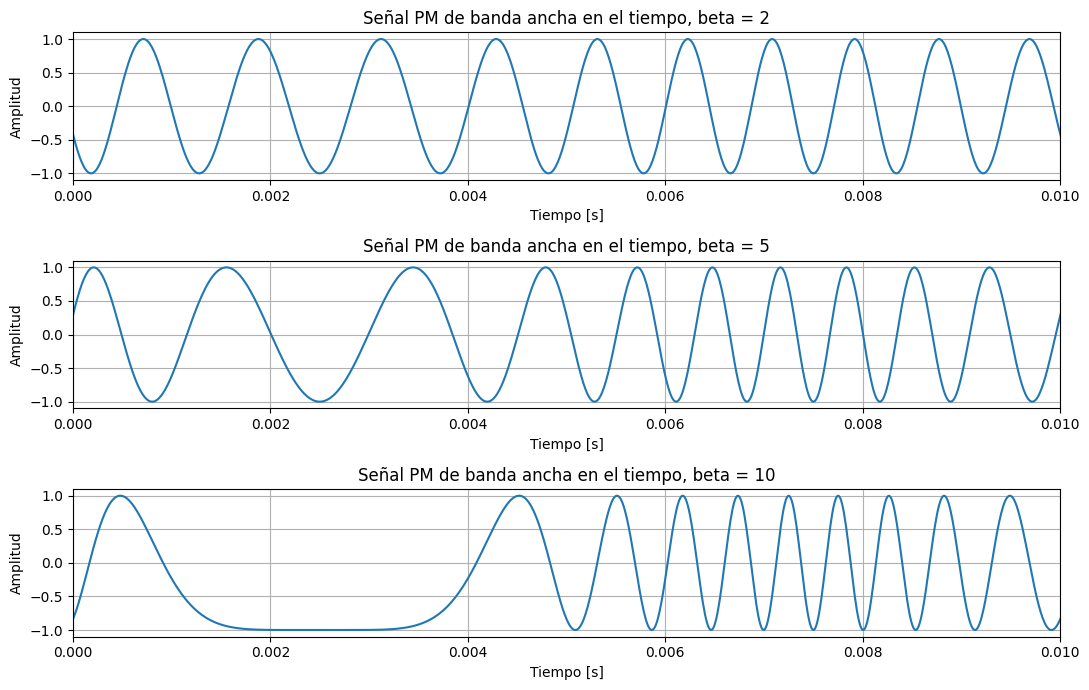

In [20]:
from scipy.special import jv

# Índices de modulación para PM de banda ancha
betas_wb = [2, 5, 10]

# Generación de señales PM de banda ancha
senales_pm_wb = {}

for beta in betas_wb:
    senales_pm_wb[beta] = Ac * np.cos(
        2 * np.pi * fc * t + beta * np.cos(2 * np.pi * fm * t)
    )

plt.figure(figsize=(11, 7))

for i, beta in enumerate(betas_wb, 1):
    plt.subplot(3, 1, i)
    plt.plot(t, senales_pm_wb[beta])
    plt.title(f"Señal PM de banda ancha en el tiempo, beta = {beta}")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud")
    plt.xlim(0, 0.01)
    plt.grid(True)

plt.tight_layout()
plt.show()


# Cálculo del espectro en PM de banda ancha

La modulación en fase, PM, se define como:

$$
s(t)=A_c\cos\left(\omega_c t+k_p x(t)\right)
$$

donde $A_c$ es la amplitud de la portadora, $\omega_c=2\pi f_c$ es la frecuencia angular de la portadora, $k_p$ es la sensibilidad de fase y $x(t)$ es la señal moduladora. En PM, la señal moduladora modifica directamente la fase instantánea de la portadora:

$$
\theta_i(t)=\omega_c t+k_p x(t)
$$

Por tanto, la señal PM puede verse como una señal de amplitud constante cuya fase varía en función de $x(t)$.

En PM de banda angosta se cumple que la desviación máxima de fase es pequeña:

$$
|k_p x(t)| \ll 1
$$

Bajo esa condición se puede usar la aproximación:

$$
e^{j k_p x(t)} \approx 1+jk_p x(t)
$$

Sin embargo, en PM de banda ancha esta aproximación ya no es válida porque:

$$
|k_p x(t)| \not\ll 1
$$

Esto significa que la fase instantánea puede variar de forma considerable. Por tanto, el espectro de la señal PM ya no contiene únicamente la portadora y dos bandas laterales principales, sino múltiples componentes espectrales alrededor de la frecuencia portadora.

Para calcular el espectro de una señal PM de banda ancha, se parte de la forma compleja de la señal. Usando la identidad de Euler:

$$
\cos(\theta)=\Re\{e^{j\theta}\}
$$

se puede escribir:

$$
s(t)=\Re\left\{A_c e^{j(\omega_c t+k_p x(t))}\right\}
$$

Separando los términos:

$$
s(t)=\Re\left\{A_c e^{j\omega_c t}e^{j k_p x(t)}\right\}
$$

El término fundamental para el análisis espectral es:

$$
g(t)=e^{j k_p x(t)}
$$

Por tanto, el espectro de PM banda ancha depende de la transformada de Fourier de $g(t)$:

$$
G(\omega)=\mathcal{F}\left\{e^{j k_p x(t)}\right\}
$$

Si:

$$
G(\omega)=\mathcal{F}\{g(t)\}
$$

entonces el término $e^{j\omega_c t}g(t)$ desplaza el espectro $G(\omega)$ alrededor de la frecuencia portadora $\omega_c$. Por la propiedad de desplazamiento en frecuencia:

$$
\mathcal{F}\left\{g(t)e^{j\omega_c t}\right\}
=
G(\omega-\omega_c)
$$

Como la señal PM real contiene también la componente conjugada, el espectro completo aparece alrededor de $+\omega_c$ y $-\omega_c$. Por esta razón, en PM de banda ancha no se desplaza directamente el espectro de $x(t)$, sino el espectro de:

$$
e^{j k_p x(t)}
$$

Esta es la diferencia clave frente a modulaciones lineales como AM o DSB.

En banda angosta, como $|k_p x(t)|$ es pequeño, se puede aproximar:

$$
e^{j k_p x(t)} \approx 1+jk_p x(t)
$$

Entonces:

$$
s(t)
\approx
\Re\left\{
A_c e^{j\omega_c t}
\left[1+jk_p x(t)\right]
\right\}
$$

Esto genera principalmente una componente de portadora en $f_c$ y dos bandas laterales alrededor de $f_c$, relacionadas con el espectro de $x(t)$. Por eso, en banda angosta el espectro de PM se parece al de una modulación DSB, con componentes dominantes en:

$$
f_c-f_m,\qquad f_c,\qquad f_c+f_m
$$

En cambio, en banda ancha no se puede usar esa aproximación. El término $e^{j k_p x(t)}$ debe mantenerse completo, lo que produce múltiples bandas laterales.

Para el caso particular de una señal moduladora senoidal:

$$
x(t)=A_m\cos(\omega_m t)
$$

la señal PM queda:

$$
s(t)=A_c\cos\left(\omega_c t+k_p A_m\cos(\omega_m t)\right)
$$

Se define el índice de modulación de fase como:

$$
\beta=k_p A_m
$$

Por tanto:

$$
s(t)=A_c\cos\left(\omega_c t+\beta\cos(\omega_m t)\right)
$$

Cuando $\beta$ es grande, la señal corresponde a PM de banda ancha.

Para calcular el espectro de esta señal se usa la expansión en funciones de Bessel:

$$
e^{j\beta\cos(\omega_m t)}
=
\sum_{n=-\infty}^{\infty}
j^n J_n(\beta)e^{jn\omega_m t}
$$

donde $J_n(\beta)$ es la función de Bessel de primera especie y orden $n$. Como:

$$
s(t)=\Re\left\{A_c e^{j\omega_c t}e^{j\beta\cos(\omega_m t)}\right\}
$$

sustituyendo la expansión de Bessel:

$$
s(t)
=
\Re\left\{
A_c e^{j\omega_c t}
\sum_{n=-\infty}^{\infty}
j^n J_n(\beta)e^{jn\omega_m t}
\right\}
$$

Agrupando los exponentes:

$$
s(t)
=
\Re\left\{
A_c
\sum_{n=-\infty}^{\infty}
j^n J_n(\beta)
e^{j(\omega_c+n\omega_m)t}
\right\}
$$

De esta expresión se observa que aparecen componentes espectrales en:

$$
\omega=\omega_c+n\omega_m
$$

o, en frecuencia en Hz:

$$
f=f_c+n f_m
$$

donde:

$$
n=0,\pm1,\pm2,\pm3,\ldots
$$

Por tanto, las componentes aparecen en:

$$
f_c,\qquad f_c\pm f_m,\qquad f_c\pm 2f_m,\qquad f_c\pm 3f_m,\ldots
$$

La amplitud de cada componente depende de:

$$
J_n(\beta)
$$

La componente en la frecuencia de la portadora $f_c$ está asociada con $J_0(\beta)$. Las primeras bandas laterales, ubicadas en $f_c\pm f_m$, están asociadas con $J_1(\beta)$. Las segundas bandas laterales, ubicadas en $f_c\pm 2f_m$, están asociadas con $J_2(\beta)$. En general, las bandas laterales ubicadas en $f_c\pm n f_m$ tienen amplitud relacionada con $J_n(\beta)$.

Cuando $\beta$ aumenta, más valores de $J_n(\beta)$ tienen magnitud significativa. Por eso, al aumentar $\beta$, el espectro se ensancha.

Teóricamente, la expansión de Bessel tiene infinitos términos:

$$
e^{j\beta\cos(\omega_m t)}
=
\sum_{n=-\infty}^{\infty}
j^n J_n(\beta)e^{jn\omega_m t}
$$

Esto significa que, en teoría, una señal PM de banda ancha tiene infinitas bandas laterales. Por tanto, el ancho de banda teórico es infinito. Sin embargo, en la práctica no todas las bandas laterales tienen amplitud importante. Muchas componentes tienen amplitudes muy pequeñas y se pueden despreciar. Por eso se define un ancho de banda práctico, considerando únicamente las bandas laterales significativas.

Para estimar el ancho de banda práctico se usa la regla de Carson:

$$
B_T \approx 2(\Delta f+f_m)
$$

donde $\Delta f$ es la desviación máxima de frecuencia y $f_m$ es la frecuencia máxima de la señal moduladora.

En PM, la fase instantánea para una moduladora senoidal es:

$$
\theta_i(t)=2\pi f_c t+\beta\cos(2\pi f_m t)
$$

La frecuencia instantánea se obtiene como:

$$
f_i(t)=\frac{1}{2\pi}\frac{d\theta_i(t)}{dt}
$$

Derivando:

$$
\frac{d\theta_i(t)}{dt}
=
2\pi f_c-\beta 2\pi f_m \sin(2\pi f_m t)
$$

Entonces:

$$
f_i(t)=f_c-\beta f_m\sin(2\pi f_m t)
$$

La desviación máxima de frecuencia es:

$$
\Delta f=\beta f_m
$$

Por tanto, para PM con moduladora senoidal:

$$
B_T\approx 2(\beta f_m+f_m)
$$

Factorizando:

$$
B_T\approx 2f_m(\beta+1)
$$

En PM banda ancha, la fase de la portadora cambia de forma considerable debido a la señal moduladora. Esto hace que la señal ya no pueda describirse únicamente como una portadora más dos bandas laterales. El término:

$$
e^{j\beta\cos(\omega_m t)}
$$

contiene muchas componentes armónicas de la frecuencia moduladora $\omega_m$. Al multiplicarse por la portadora $e^{j\omega_c t}$, esas componentes se trasladan alrededor de la frecuencia portadora. Por eso aparecen componentes en:

$$
f_c\pm nf_m
$$

A mayor $\beta$, mayor es la desviación de fase, y más bandas laterales tienen amplitud significativa. En consecuencia, la señal PM de banda ancha ocupa un ancho de banda mayor que la PM de banda angosta.

En simulación, el espectro se puede calcular directamente aplicando la FFT a la señal PM:

$$
s(t)=A_c\cos\left(2\pi f_c t+\beta\cos(2\pi f_m t)\right)
$$

La FFT permite observar numéricamente las componentes espectrales en:

$$
f_c\pm nf_m
$$

Esto coincide con el resultado teórico obtenido mediante la expansión de Bessel. Por tanto, la gráfica del espectro debe mostrar una componente alrededor de $f_c$, varias bandas laterales alrededor de $f_c$ y una mayor cantidad de bandas significativas cuando aumenta $\beta$.

En resumen, el procedimiento teórico para calcular el espectro de PM banda ancha es:

1. Partir de la señal PM:

$$
s(t)=A_c\cos\left(\omega_c t+k_p x(t)\right)
$$

2. Escribirla en forma compleja:

$$
s(t)=\Re\left\{A_c e^{j\omega_c t}e^{jk_p x(t)}\right\}
$$

3. Identificar el término que realmente determina el espectro:

$$
g(t)=e^{jk_p x(t)}
$$

4. Calcular o analizar:

$$
G(\omega)=\mathcal{F}\{g(t)\}
$$

5. Desplazar ese espectro alrededor de la portadora:

$$
G(\omega-\omega_c)
$$

6. Para el caso senoidal, usar la expansión de Bessel:

$$
e^{j\beta\cos(\omega_m t)}
=
\sum_{n=-\infty}^{\infty}
j^nJ_n(\beta)e^{jn\omega_m t}
$$

7. Concluir que las componentes aparecen en:

$$
f_c\pm nf_m
$$

con amplitudes relacionadas con:

$$
J_n(\beta)
$$

Por eso, en PM banda ancha el espectro contiene múltiples bandas laterales y su ancho de banda práctico aumenta con el índice de modulación $\beta$.

La idea central es que en PM de banda ancha el espectro no se obtiene desplazando directamente el espectro de la señal moduladora $x(t)$. El espectro se obtiene a partir del término no lineal:

$$
e^{jk_p x(t)}
$$

Por tanto, se debe analizar:

$$
\mathcal{F}\left\{e^{jk_p x(t)}\right\}
$$

y luego desplazar ese resultado alrededor de la frecuencia portadora.# Cálculo del espectro en PM de banda ancha

La modulación en fase, PM, se define como:

$$
s(t)=A_c\cos\left(\omega_c t+k_p x(t)\right)
$$

donde $A_c$ es la amplitud de la portadora, $\omega_c=2\pi f_c$ es la frecuencia angular de la portadora, $k_p$ es la sensibilidad de fase y $x(t)$ es la señal moduladora. En PM, la señal moduladora modifica directamente la fase instantánea de la portadora:

$$
\theta_i(t)=\omega_c t+k_p x(t)
$$

Por tanto, la señal PM puede verse como una señal de amplitud constante cuya fase varía en función de $x(t)$.

En PM de banda angosta se cumple que la desviación máxima de fase es pequeña:

$$
|k_p x(t)| \ll 1
$$

Bajo esa condición se puede usar la aproximación:

$$
e^{j k_p x(t)} \approx 1+jk_p x(t)
$$

Sin embargo, en PM de banda ancha esta aproximación ya no es válida porque:

$$
|k_p x(t)| \not\ll 1
$$

Esto significa que la fase instantánea puede variar de forma considerable. Por tanto, el espectro de la señal PM ya no contiene únicamente la portadora y dos bandas laterales principales, sino múltiples componentes espectrales alrededor de la frecuencia portadora.

Para calcular el espectro de una señal PM de banda ancha, se parte de la forma compleja de la señal. Usando la identidad de Euler:

$$
\cos(\theta)=\Re\{e^{j\theta}\}
$$

se puede escribir:

$$
s(t)=\Re\left\{A_c e^{j(\omega_c t+k_p x(t))}\right\}
$$

Separando los términos:

$$
s(t)=\Re\left\{A_c e^{j\omega_c t}e^{j k_p x(t)}\right\}
$$

El término fundamental para el análisis espectral es:

$$
g(t)=e^{j k_p x(t)}
$$

Por tanto, el espectro de PM banda ancha depende de la transformada de Fourier de $g(t)$:

$$
G(\omega)=\mathcal{F}\left\{e^{j k_p x(t)}\right\}
$$

Si:

$$
G(\omega)=\mathcal{F}\{g(t)\}
$$

entonces el término $e^{j\omega_c t}g(t)$ desplaza el espectro $G(\omega)$ alrededor de la frecuencia portadora $\omega_c$. Por la propiedad de desplazamiento en frecuencia:

$$
\mathcal{F}\left\{g(t)e^{j\omega_c t}\right\}
=
G(\omega-\omega_c)
$$

Como la señal PM real contiene también la componente conjugada, el espectro completo aparece alrededor de $+\omega_c$ y $-\omega_c$. Por esta razón, en PM de banda ancha no se desplaza directamente el espectro de $x(t)$, sino el espectro de:

$$
e^{j k_p x(t)}
$$

Esta es la diferencia clave frente a modulaciones lineales como AM o DSB.

En banda angosta, como $|k_p x(t)|$ es pequeño, se puede aproximar:

$$
e^{j k_p x(t)} \approx 1+jk_p x(t)
$$

Entonces:

$$
s(t)
\approx
\Re\left\{
A_c e^{j\omega_c t}
\left[1+jk_p x(t)\right]
\right\}
$$

Esto genera principalmente una componente de portadora en $f_c$ y dos bandas laterales alrededor de $f_c$, relacionadas con el espectro de $x(t)$. Por eso, en banda angosta el espectro de PM se parece al de una modulación DSB, con componentes dominantes en:

$$
f_c-f_m,\qquad f_c,\qquad f_c+f_m
$$

En cambio, en banda ancha no se puede usar esa aproximación. El término $e^{j k_p x(t)}$ debe mantenerse completo, lo que produce múltiples bandas laterales.

Para el caso particular de una señal moduladora senoidal:

$$
x(t)=A_m\cos(\omega_m t)
$$

la señal PM queda:

$$
s(t)=A_c\cos\left(\omega_c t+k_p A_m\cos(\omega_m t)\right)
$$

Se define el índice de modulación de fase como:

$$
\beta=k_p A_m
$$

Por tanto:

$$
s(t)=A_c\cos\left(\omega_c t+\beta\cos(\omega_m t)\right)
$$

Cuando $\beta$ es grande, la señal corresponde a PM de banda ancha.

Para calcular el espectro de esta señal se usa la expansión en funciones de Bessel:

$$
e^{j\beta\cos(\omega_m t)}
=
\sum_{n=-\infty}^{\infty}
j^n J_n(\beta)e^{jn\omega_m t}
$$

donde $J_n(\beta)$ es la función de Bessel de primera especie y orden $n$. Como:

$$
s(t)=\Re\left\{A_c e^{j\omega_c t}e^{j\beta\cos(\omega_m t)}\right\}
$$

sustituyendo la expansión de Bessel:

$$
s(t)
=
\Re\left\{
A_c e^{j\omega_c t}
\sum_{n=-\infty}^{\infty}
j^n J_n(\beta)e^{jn\omega_m t}
\right\}
$$

Agrupando los exponentes:

$$
s(t)
=
\Re\left\{
A_c
\sum_{n=-\infty}^{\infty}
j^n J_n(\beta)
e^{j(\omega_c+n\omega_m)t}
\right\}
$$

De esta expresión se observa que aparecen componentes espectrales en:

$$
\omega=\omega_c+n\omega_m
$$

o, en frecuencia en Hz:

$$
f=f_c+n f_m
$$

donde:

$$
n=0,\pm1,\pm2,\pm3,\ldots
$$

Por tanto, las componentes aparecen en:

$$
f_c,\qquad f_c\pm f_m,\qquad f_c\pm 2f_m,\qquad f_c\pm 3f_m,\ldots
$$

La amplitud de cada componente depende de:

$$
J_n(\beta)
$$

La componente en la frecuencia de la portadora $f_c$ está asociada con $J_0(\beta)$. Las primeras bandas laterales, ubicadas en $f_c\pm f_m$, están asociadas con $J_1(\beta)$. Las segundas bandas laterales, ubicadas en $f_c\pm 2f_m$, están asociadas con $J_2(\beta)$. En general, las bandas laterales ubicadas en $f_c\pm n f_m$ tienen amplitud relacionada con $J_n(\beta)$.

Cuando $\beta$ aumenta, más valores de $J_n(\beta)$ tienen magnitud significativa. Por eso, al aumentar $\beta$, el espectro se ensancha.

Teóricamente, la expansión de Bessel tiene infinitos términos:

$$
e^{j\beta\cos(\omega_m t)}
=
\sum_{n=-\infty}^{\infty}
j^n J_n(\beta)e^{jn\omega_m t}
$$

Esto significa que, en teoría, una señal PM de banda ancha tiene infinitas bandas laterales. Por tanto, el ancho de banda teórico es infinito. Sin embargo, en la práctica no todas las bandas laterales tienen amplitud importante. Muchas componentes tienen amplitudes muy pequeñas y se pueden despreciar. Por eso se define un ancho de banda práctico, considerando únicamente las bandas laterales significativas.

Para estimar el ancho de banda práctico se usa la regla de Carson:

$$
B_T \approx 2(\Delta f+f_m)
$$

donde $\Delta f$ es la desviación máxima de frecuencia y $f_m$ es la frecuencia máxima de la señal moduladora.

En PM, la fase instantánea para una moduladora senoidal es:

$$
\theta_i(t)=2\pi f_c t+\beta\cos(2\pi f_m t)
$$

La frecuencia instantánea se obtiene como:

$$
f_i(t)=\frac{1}{2\pi}\frac{d\theta_i(t)}{dt}
$$

Derivando:

$$
\frac{d\theta_i(t)}{dt}
=
2\pi f_c-\beta 2\pi f_m \sin(2\pi f_m t)
$$

Entonces:

$$
f_i(t)=f_c-\beta f_m\sin(2\pi f_m t)
$$

La desviación máxima de frecuencia es:

$$
\Delta f=\beta f_m
$$

Por tanto, para PM con moduladora senoidal:

$$
B_T\approx 2(\beta f_m+f_m)
$$

Factorizando:

$$
B_T\approx 2f_m(\beta+1)
$$

En PM banda ancha, la fase de la portadora cambia de forma considerable debido a la señal moduladora. Esto hace que la señal ya no pueda describirse únicamente como una portadora más dos bandas laterales. El término:

$$
e^{j\beta\cos(\omega_m t)}
$$

contiene muchas componentes armónicas de la frecuencia moduladora $\omega_m$. Al multiplicarse por la portadora $e^{j\omega_c t}$, esas componentes se trasladan alrededor de la frecuencia portadora. Por eso aparecen componentes en:

$$
f_c\pm nf_m
$$

A mayor $\beta$, mayor es la desviación de fase, y más bandas laterales tienen amplitud significativa. En consecuencia, la señal PM de banda ancha ocupa un ancho de banda mayor que la PM de banda angosta.

En simulación, el espectro se puede calcular directamente aplicando la FFT a la señal PM:

$$
s(t)=A_c\cos\left(2\pi f_c t+\beta\cos(2\pi f_m t)\right)
$$

La FFT permite observar numéricamente las componentes espectrales en:

$$
f_c\pm nf_m
$$

Esto coincide con el resultado teórico obtenido mediante la expansión de Bessel. Por tanto, la gráfica del espectro debe mostrar una componente alrededor de $f_c$, varias bandas laterales alrededor de $f_c$ y una mayor cantidad de bandas significativas cuando aumenta $\beta$.

En resumen, el procedimiento teórico para calcular el espectro de PM banda ancha es:

1. Partir de la señal PM:

$$
s(t)=A_c\cos\left(\omega_c t+k_p x(t)\right)
$$

2. Escribirla en forma compleja:

$$
s(t)=\Re\left\{A_c e^{j\omega_c t}e^{jk_p x(t)}\right\}
$$

3. Identificar el término que realmente determina el espectro:

$$
g(t)=e^{jk_p x(t)}
$$

4. Calcular o analizar:

$$
G(\omega)=\mathcal{F}\{g(t)\}
$$

5. Desplazar ese espectro alrededor de la portadora:

$$
G(\omega-\omega_c)
$$

6. Para el caso senoidal, usar la expansión de Bessel:

$$
e^{j\beta\cos(\omega_m t)}
=
\sum_{n=-\infty}^{\infty}
j^nJ_n(\beta)e^{jn\omega_m t}
$$

7. Concluir que las componentes aparecen en:

$$
f_c\pm nf_m
$$

con amplitudes relacionadas con:

$$
J_n(\beta)
$$

Por eso, en PM banda ancha el espectro contiene múltiples bandas laterales y su ancho de banda práctico aumenta con el índice de modulación $\beta$.

La idea central es que en PM de banda ancha el espectro no se obtiene desplazando directamente el espectro de la señal moduladora $x(t)$. El espectro se obtiene a partir del término no lineal:

$$
e^{jk_p x(t)}
$$

Por tanto, se debe analizar:

$$
\mathcal{F}\left\{e^{jk_p x(t)}\right\}
$$

y luego desplazar ese resultado alrededor de la frecuencia portadora.

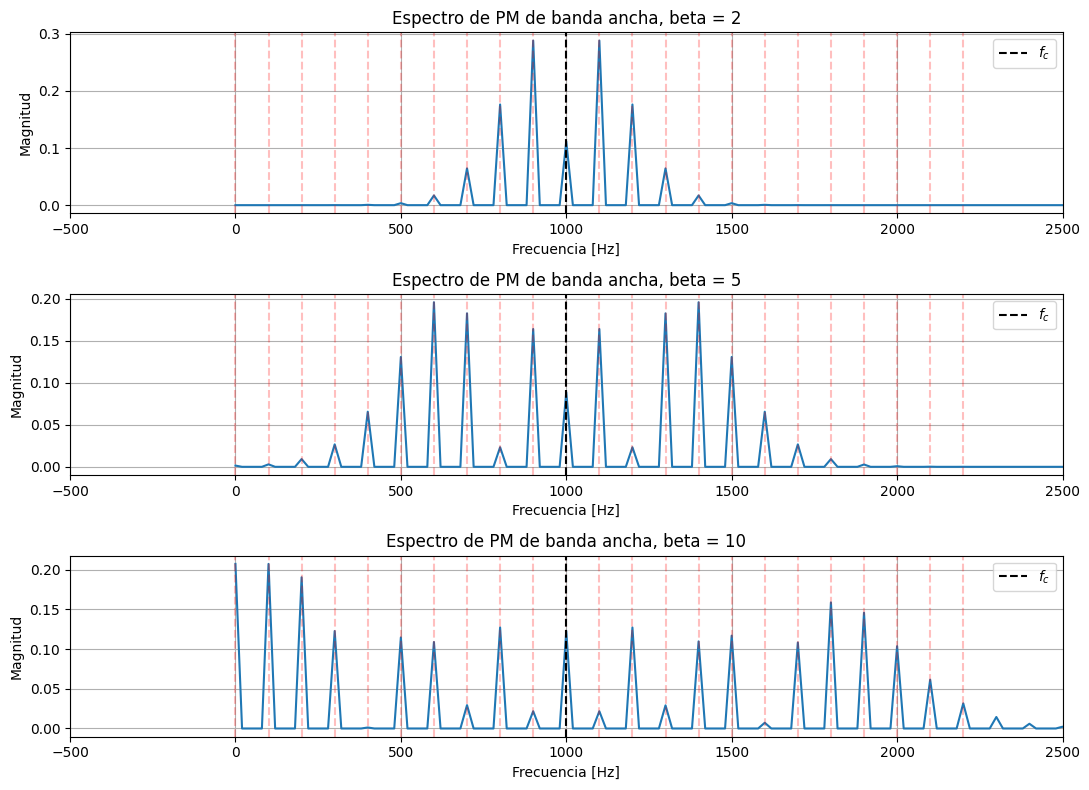

In [21]:
plt.figure(figsize=(11, 8))

for i, beta in enumerate(betas_wb, 1):
    f_wb, S_wb = calcular_espectro(senales_pm_wb[beta], fs)

    plt.subplot(3, 1, i)
    plt.plot(f_wb, S_wb)

    # Líneas en fc ± nfm
    for n in range(-12, 13):
        frecuencia_lateral = fc + n * fm
        if frecuencia_lateral >= 0:
            plt.axvline(frecuencia_lateral, color="red", linestyle="--", alpha=0.25)

    plt.axvline(fc, color="black", linestyle="--", label="$f_c$")
    plt.title(f"Espectro de PM de banda ancha, beta = {beta}")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Magnitud")
    plt.xlim(fc - 15*fm, fc + 15*fm)
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()


### Amplitud de las bandas laterales

En PM de banda ancha, la amplitud de las componentes espectrales está relacionada con las funciones de Bessel:

$$
J_n(\beta)
$$

Cada valor de $n$ representa un par de bandas laterales ubicadas en:

$$
f_c - nf_m
$$

y

$$
f_c + nf_m
$$

Cuando $\beta$ aumenta, más valores de $J_n(\beta)$ tienen magnitud significativa. Esto significa que aparecen más bandas laterales importantes alrededor de la portadora.

Por eso, al aumentar $\beta$, el espectro se ensancha.


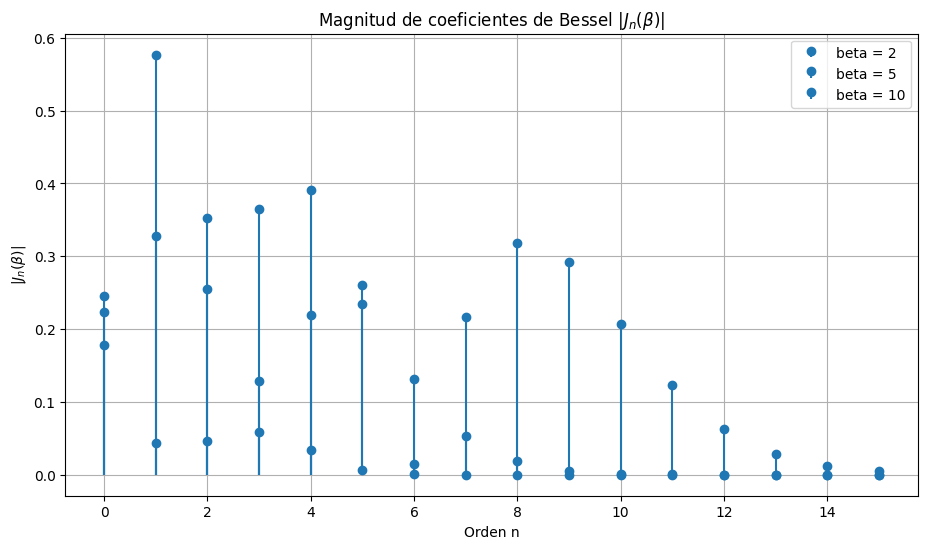

In [22]:
ordenes = np.arange(0, 16)

plt.figure(figsize=(11, 6))

for beta in betas_wb:
    amplitudes_bessel = np.abs(jv(ordenes, beta))
    plt.stem(
        ordenes,
        amplitudes_bessel,
        label=f"beta = {beta}",
        basefmt=" "
    )

plt.title("Magnitud de coeficientes de Bessel $|J_n(\\beta)|$")
plt.xlabel("Orden n")
plt.ylabel("$|J_n(\\beta)|$")
plt.grid(True)
plt.legend()
plt.show()


## Análisis espectral

El análisis espectral permite observar cómo se distribuye la energía de la señal PM en frecuencia.

Para banda angosta, con $\beta \ll 1$, el espectro se concentra principalmente en:

$$
f_c - f_m
$$

$$
f_c
$$

$$
f_c + f_m
$$

Por tanto, aparecen principalmente dos bandas laterales alrededor de la portadora.

Para banda ancha, con $\beta > 1$, aparecen múltiples bandas laterales en:

$$
f_c \pm nf_m
$$

A medida que $\beta$ aumenta, aumenta el número de bandas laterales significativas. Esto hace que el ancho de banda ocupado por la señal sea mayor.


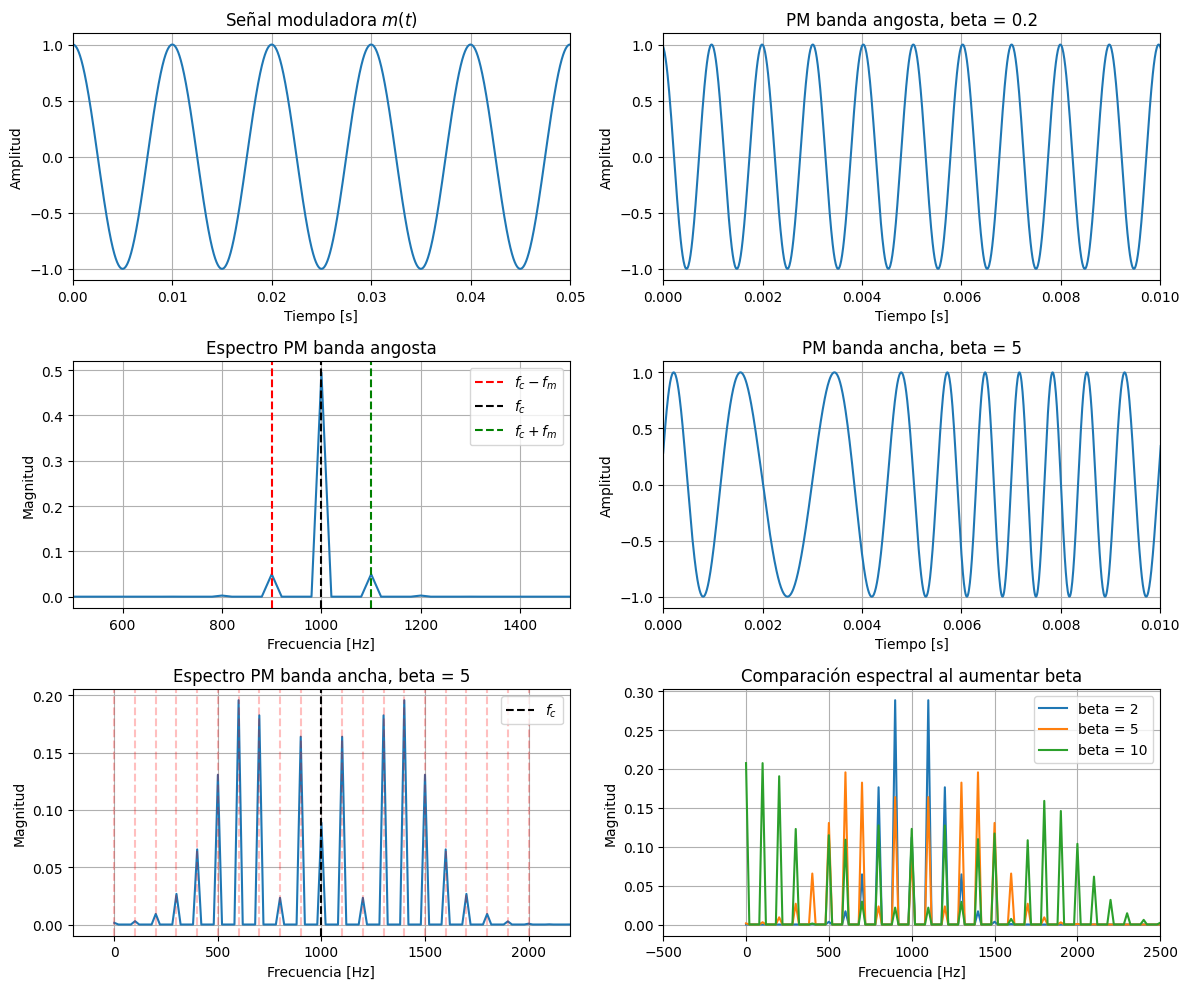

In [23]:
plt.figure(figsize=(12, 10))

# Señal moduladora
plt.subplot(3, 2, 1)
plt.plot(t, m_t)
plt.title("Señal moduladora $m(t)$")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.xlim(0, 0.05)
plt.grid(True)

# PM banda angosta en el tiempo
plt.subplot(3, 2, 2)
plt.plot(t, s_pm_nb)
plt.title(f"PM banda angosta, beta = {beta_nb}")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.xlim(0, 0.01)
plt.grid(True)

# Espectro banda angosta
plt.subplot(3, 2, 3)
plt.plot(f_nb, S_nb)
plt.axvline(fc - fm, color="red", linestyle="--", label="$f_c-f_m$")
plt.axvline(fc, color="black", linestyle="--", label="$f_c$")
plt.axvline(fc + fm, color="green", linestyle="--", label="$f_c+f_m$")
plt.title("Espectro PM banda angosta")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(fc - 5*fm, fc + 5*fm)
plt.grid(True)
plt.legend()

# PM banda ancha en el tiempo, beta = 5
beta_referencia = 5
plt.subplot(3, 2, 4)
plt.plot(t, senales_pm_wb[beta_referencia])
plt.title(f"PM banda ancha, beta = {beta_referencia}")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.xlim(0, 0.01)
plt.grid(True)

# Espectro banda ancha, beta = 5
f_ref, S_ref = calcular_espectro(senales_pm_wb[beta_referencia], fs)

plt.subplot(3, 2, 5)
plt.plot(f_ref, S_ref)

for n in range(-10, 11):
    frecuencia_lateral = fc + n * fm
    if frecuencia_lateral >= 0:
        plt.axvline(frecuencia_lateral, color="red", linestyle="--", alpha=0.25)

plt.axvline(fc, color="black", linestyle="--", label="$f_c$")
plt.title(f"Espectro PM banda ancha, beta = {beta_referencia}")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(fc - 12*fm, fc + 12*fm)
plt.grid(True)
plt.legend()

# Comparación espectral para beta = 2, 5, 10
plt.subplot(3, 2, 6)

for beta in betas_wb:
    f_temp, S_temp = calcular_espectro(senales_pm_wb[beta], fs)
    plt.plot(f_temp, S_temp, label=f"beta = {beta}")

plt.title("Comparación espectral al aumentar beta")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(fc - 15*fm, fc + 15*fm)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


## Ancho de banda práctico

Aunque el ancho de banda teórico de una señal PM de banda ancha tiende a infinito, en la práctica solo se consideran las bandas laterales con amplitud significativa.

Para estimar el ancho de banda práctico se usa la regla de Carson:

$$
B \approx 2(\Delta f + f_m)
$$

donde $\Delta f$ es la desviación máxima de frecuencia.

En PM, la fase instantánea es:

$$
\theta_i(t) = 2\pi f_c t + \beta \cos(2\pi f_m t)
$$

La frecuencia instantánea se obtiene derivando la fase y dividiendo entre $2\pi$:

$$
f_i(t) = \frac{1}{2\pi}\frac{d\theta_i(t)}{dt}
$$

Derivando:

$$
\frac{d\theta_i(t)}{dt}
=
2\pi f_c - \beta 2\pi f_m \sin(2\pi f_m t)
$$

Entonces:

$$
f_i(t)
=
f_c - \beta f_m \sin(2\pi f_m t)
$$

La máxima desviación de frecuencia ocurre cuando:

$$
|\sin(2\pi f_m t)| = 1
$$

Por tanto:

$$
\Delta f = \beta f_m
$$

Sustituyendo en la regla de Carson:

$$
B \approx 2(\beta f_m + f_m)
$$

Factorizando:

$$
B \approx 2f_m(\beta + 1)
$$

Para banda angosta se obtuvo:

$$
B \approx 2f_m
$$

Por lo tanto, el ancho de banda práctico en banda ancha aumenta directamente con el índice de modulación $\beta$.


Comparación de ancho de banda
Ancho de banda en PM de banda angosta: B ≈ 2fm = 200 Hz

Beta = 2
Desviación máxima de frecuencia Δf = beta * fm = 200 Hz
Ancho de banda práctico por Carson B ≈ 2(Δf + fm) = 600 Hz

Beta = 5
Desviación máxima de frecuencia Δf = beta * fm = 500 Hz
Ancho de banda práctico por Carson B ≈ 2(Δf + fm) = 1200 Hz

Beta = 10
Desviación máxima de frecuencia Δf = beta * fm = 1000 Hz
Ancho de banda práctico por Carson B ≈ 2(Δf + fm) = 2200 Hz



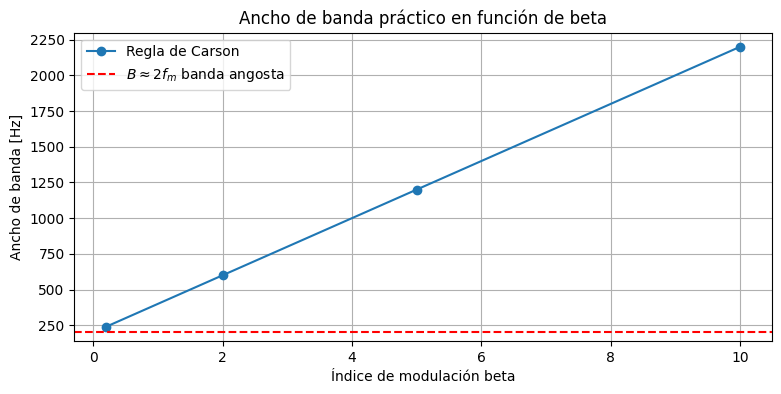

In [24]:
# Ancho de banda de banda angosta
B_nb = 2 * fm

print("Comparación de ancho de banda")
print(f"Ancho de banda en PM de banda angosta: B ≈ 2fm = {B_nb} Hz")
print()

for beta in betas_wb:
    delta_f = beta * fm
    B_carson = 2 * (delta_f + fm)

    print(f"Beta = {beta}")
    print(f"Desviación máxima de frecuencia Δf = beta * fm = {delta_f} Hz")
    print(f"Ancho de banda práctico por Carson B ≈ 2(Δf + fm) = {B_carson} Hz")
    print()

# Gráfica comparativa
betas_comparacion = np.array([0.2, 2, 5, 10])
anchos_banda_carson = 2 * fm * (betas_comparacion + 1)

plt.figure(figsize=(9, 4))
plt.plot(betas_comparacion, anchos_banda_carson, marker="o", label="Regla de Carson")
plt.axhline(B_nb, color="red", linestyle="--", label="$B \\approx 2f_m$ banda angosta")

plt.title("Ancho de banda práctico en función de beta")
plt.xlabel("Índice de modulación beta")
plt.ylabel("Ancho de banda [Hz]")
plt.grid(True)
plt.legend()
plt.show()


## Comparación final

| Aspecto | PM de banda angosta | PM de banda ancha |
|---|---|---|
| Índice de modulación | $\beta \ll 1$ | $\beta > 1$ |
| Aproximación matemática | Se puede usar aproximación de ángulo pequeño | Se requiere expansión con funciones de Bessel |
| Componentes principales | Portadora y dos bandas laterales | Portadora y múltiples bandas laterales |
| Frecuencias presentes | $f_c$, $f_c-f_m$, $f_c+f_m$ | $f_c \pm nf_m$, con $n=1,2,3,\ldots$ |
| Relación con DSB | Alta, porque aparecen dos bandas laterales alrededor de la portadora | No es directa, porque aparecen muchas bandas laterales |
| Ancho de banda teórico | Finito, aproximadamente $2f_m$ | Infinito, porque teóricamente hay infinitas bandas laterales |
| Ancho de banda práctico | $B \approx 2f_m$ | $B \approx 2f_m(\beta+1)$ usando Carson |
| Efecto de aumentar $\beta$ | La señal permanece concentrada cerca de $f_c$ | El espectro se ensancha y aparecen más bandas laterales significativas |

En PM de banda angosta, el ancho de banda es finito porque solo se consideran significativas la portadora y las dos bandas laterales principales. Matemáticamente, estas componentes ocupan desde $f_c-f_m$ hasta $f_c+f_m$, por lo que:

$$
B \approx 2f_m
$$

Este resultado coincide con el comportamiento de una modulación DSB, cuyo ancho de banda también depende del doble de la frecuencia máxima de la señal moduladora.

En PM de banda ancha, el aumento de $\beta$ hace que más coeficientes de Bessel tengan amplitud significativa. Por eso aparecen más componentes espectrales en $f_c \pm nf_m$. Como teóricamente existen componentes para infinitos valores de $n$, el ancho de banda teórico tiende a infinito.

En la práctica, no todas esas componentes se consideran relevantes. Por eso se usa la regla de Carson:

$$
B \approx 2(\Delta f + f_m)
$$

y para PM sinusoidal:

$$
B \approx 2f_m(\beta+1)
$$

Esto demuestra que el índice de modulación $\beta$ controla directamente la expansión del espectro: a mayor $\beta$, mayor número de bandas laterales significativas y mayor ancho de banda práctico.
